# 01 · Cohort and outcomes

The case study follows a hand-curated cohort of 43 hitting prospects who reached the majors between 2020 and 2025: six developed by the Yankees, nineteen from five other organizations, and eighteen from elsewhere. It is not a systematic sample, so results describe these players rather than all prospects.

This notebook fixes one outcome definition that every later notebook uses:

**Outcome = wOBA over a player's first 600 MLB regular-season plate appearances**, labeled star (≥ .340), solid (.310–.339), disappointing (.280–.309), or bust (< .280). A player who has not yet reached 600 PA is labeled *insufficient* rather than guessed at. Counting plate appearances instead of calendar seasons keeps injuries and September call-ups from shrinking the sample.

wOBA uses the FanGraphs definition and season weights (see `src/yanks_analytics/features/season.py`); notebook 02 checks it against Baseball Savant's published values.

In [1]:
import sys
import warnings

warnings.filterwarnings("ignore", message=".*urllib3.*")
sys.path.insert(0, "../src")

from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

FIG_DIR = Path("../outputs/figures")
FIG_DIR.mkdir(parents=True, exist_ok=True)
DATA_DIR = Path("../outputs/data")
DATA_DIR.mkdir(parents=True, exist_ok=True)
plt.rcParams.update({"figure.dpi": 110, "axes.spines.top": False, "axes.spines.right": False,
                     "axes.grid": True, "grid.alpha": 0.3})
pd.set_option("display.precision", 3)

from yanks_analytics.data.prospects import get_prospect_df
from yanks_analytics.data.statcast import load_seasons
from yanks_analytics.features.season import first_pa_outcomes

## Cohort

MLBAM IDs and debut dates were checked against the MLB Stats API (`/api/v1/people`). The Yankees group is Volpe, Dominguez, Rice, Peraza, Pereira, and Wells.

In [2]:
cohort = get_prospect_df()
print(f"{len(cohort)} players; debut years {cohort['debut_year'].min()}-{cohort['debut_year'].max()}")
print(cohort.groupby("org").size().sort_values(ascending=False).to_string())

43 players; debut years 2020-2025
org
NYY    6
BAL    5
CLE    5
TB     3
ATL    3
LAD    3
CIN    2
DET    2
SEA    2
ARI    1
STL    1
SF     1
SD     1
LAA    1
MIN    1
MIL    1
KC     1
COL    1
CHW    1
BOS    1
TEX    1


## Outcomes

Statcast pitch data covers 2020–2026, which includes every cohort debut, so each player's plate appearances are counted from his first MLB game.

For the four players who have not reached 600 PA, `wOBA_first600` is their wOBA over all plate appearances to date and carries no label.

In [3]:
pitches = load_seasons(range(2020, 2027))
pitches = pitches[pitches["batter"].isin(cohort["mlbam_id"])]

outcomes = first_pa_outcomes(pitches, cohort["mlbam_id"], n_pa=600)
outcomes = cohort.set_index("mlbam_id")[["name", "org", "mlb_debut"]].join(outcomes)
outcomes.to_csv(DATA_DIR / "cohort_outcomes.csv")

(outcomes.sort_values("wOBA_first600", ascending=False)
 .assign(mlb_debut=lambda d: d["mlb_debut"].dt.date, reached_on=lambda d: d["reached_on"].dt.date)
 .reset_index(drop=True))

,name,org,mlb_debut,career_PA,wOBA_first600,label,reached_on
0,Julio Rodriguez,SEA,2022-04-08,3232.0,0.367,star,2023-04-09
1,Corbin Carroll,ARI,2022-08-29,2739.0,0.363,star,2023-08-19
2,Adley Rutschman,BAL,2022-05-21,2561.0,0.361,star,2023-05-02
3,Nolan Jones,CLE,2022-07-08,1209.0,0.355,star,2024-04-21
4,James Outman,LAD,2022-07-31,1056.0,0.349,star,2024-03-30
5,Gunnar Henderson,BAL,2022-08-31,2814.0,0.343,star,2023-08-25
6,Steven Kwan,CLE,2022-04-07,3205.0,0.342,star,2022-09-27
7,Michael Harris II,ATL,2022-05-28,2700.0,0.339,solid,2023-06-12
8,Jackson Chourio,MIL,2024-03-29,1723.0,0.338,solid,2025-04-03
9,Matt McLain,CIN,2023-05-15,1469.0,0.336,solid,2025-05-28


In [4]:
order = ["star", "solid", "disappointing", "bust", "insufficient"]
outcomes["label"].value_counts().reindex(order).rename("players").to_frame().T

label,star,solid,disappointing,bust,insufficient
players,7,15,11,6,4


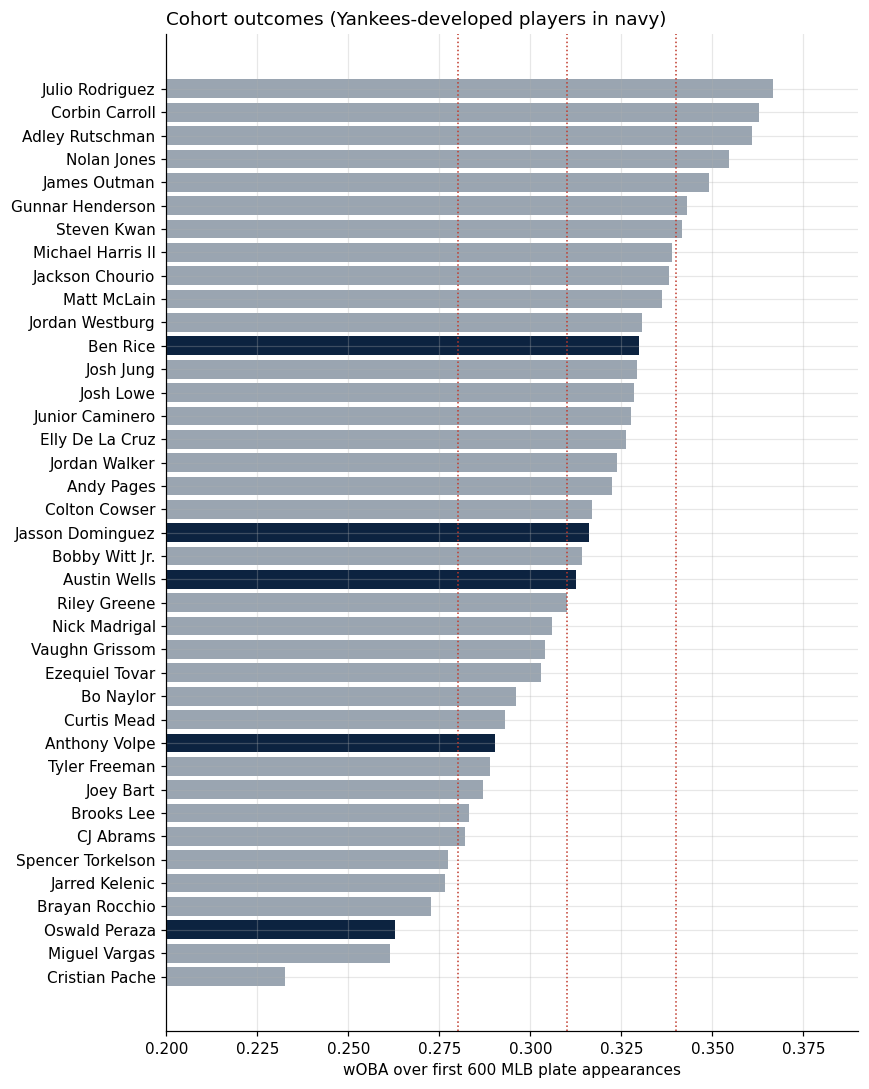

In [5]:
labeled = outcomes[outcomes["label"] != "insufficient"].sort_values("wOBA_first600")
colors = np.where(labeled["org"] == "NYY", "#0c2340", "#9aa5b1")

fig, ax = plt.subplots(figsize=(8, 10))
ax.barh(labeled["name"], labeled["wOBA_first600"], color=colors)
for cut in (0.280, 0.310, 0.340):
    ax.axvline(cut, color="#c0392b", linestyle=":", linewidth=1)
ax.set_xlim(0.2, 0.39)
ax.set_xlabel("wOBA over first 600 MLB plate appearances")
ax.set_title("Cohort outcomes (Yankees-developed players in navy)", loc="left")
fig.tight_layout()
fig.savefig(FIG_DIR / "cohort_outcomes.png", dpi=150, bbox_inches="tight")
plt.show()

## What this does not support

The five comparison organizations were chosen for their public player-development reputations when the cohort was assembled. With three to six players per organization, and selection by hand, the cohort cannot rank organizations, so no notebook in this project compares organizational success rates.